# Problema de Máxima Diversidad

Este notebook presenta una adaptación práctica del **Proyecto 9: Problema de máxima diversidad** propuesto en la oferta de trabajos de la asignatura. Originalmente enfocado en implementar un algoritmo evolutivo para maximizar la diversidad, el problema se ha trasladado al **ámbito financiero**: el objetivo es seleccionar una cartera de exactamente $m$ acciones que presenten la máxima descorrelación entre sí para minimizar el riesgo frente a caídas del mercado. El problema original de maximización se ha transformado en uno de minimización, buscando el valor negativo de la diversidad.

Para resolverlo, se extraen datos reales de las empresas del S&P 500 y se comparan dos versiones del algoritmo evolutivo para el manejo de las restricciones, tal como solicita el enunciado original:
* **AE1 (External feasibility first / Penalización)**: Aplica una penalización estricta sobre la función objetivo si la cartera generada no cumple con el número exacto de activos requeridos ($m$).
* **AE2 (Algoritmo de reparo)**: Utiliza una heurística que ajusta o "repara" dinámicamente los cromosomas generados (comprando o vendiendo activos al azar) para que la cartera cumpla con la restricción antes de evaluar su *fitness*.

Finalmente, el rendimiento algorítmico y la robustez de ambas técnicas se evalúan estadísticamente bajo diferentes escenarios de inversión (carteras pequeñas, medianas e institucionales) haciendo uso del test no paramétrico de Wilcoxon.

Primero importamos las librerías necesarias para el notebook.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import random
from scipy.stats import wilcoxon
import warnings
import logging

warnings.filterwarnings('ignore')
logger = logging.getLogger('yfinance')
logger.setLevel(logging.CRITICAL)

Para este notebook se usarán datos reales, por lo que extraeremos desde Wikipedia los integrantes del índice bursatil S&P500 y nos descargaremos dos años de historia para cada uno. Calcularemos los retornos diarios y la matriz de correlación entre ellos, a partir de la cual crearemos la matriz de distancias. Se hace una división para evitar revelar datos futuros en el proceso de selección de activos, utilizando solo una parte de la historia para la optimización y reservando el resto para evaluar el rendimiento financiero de las carteras seleccionadas.

In [2]:
START_DATE = "2014-01-01"
END_DATE = "2020-01-01"

def get_tickers():
    URL = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"
    sp500_df = pd.read_csv(URL)
    sp500_tickers = sp500_df['Symbol'].tolist()
    sp500_tickers = [str(ticker).replace('.', '-') for ticker in sp500_tickers]
    return sp500_tickers

def download_data(tickers):
    data = yf.download(tickers, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)['Adj Close']
    return data

def process_data(data):
    returns = data.pct_change().dropna(axis=0, how='all').dropna(axis=1)
    if returns.shape[1] >= 200:
        valid_tickers = returns.columns.tolist()[:200]
        returns = returns[valid_tickers]
    else:
        valid_tickers = returns.columns.tolist()
    return returns, valid_tickers

def get_correlation_matrix(returns):
    corr_matrix = returns.corr().values
    return corr_matrix

def get_distance_matrix(corr_matrix):
    distance_matrix = 1 - corr_matrix
    return distance_matrix

In [3]:
# Descarga y procesamiento inicial
tickers = get_tickers()
data = download_data(tickers)
returns, valid_tickers = process_data(data)

returns_train = returns.loc['2014-01-01':'2018-12-31'] # 2014 a 2018 para entrenar el modelo
returns_test = returns.loc['2019-01-01':'2020-01-01']  # 2019 a 2020 para backtest

corr_matrix = get_correlation_matrix(returns_train)
master_distance_matrix = get_distance_matrix(corr_matrix)

Definimos a continuación las funciones necesarias para el algoritmo evolutivo. Se utiliza selección por torneo, cruze uniforme y mutación por flip bit de probabilidad fija. La selección por torneo se implementa con un tamaño de torneo de 3, lo que significa que se seleccionan aleatoriamente 3 individuos de la población y se elige el mejor entre ellos para reproducirse. El cruce uniforme combina dos padres para crear un hijo, donde cada gen del hijo tiene una probabilidad del 50% de ser heredado de cada padre en el caso de que ocurra el cruce con una probabilidad fija. La mutación por flip bit consiste en cambiar el valor de un gen específico con una probabilidad fija, lo que introduce variabilidad en la población y ayuda a evitar la convergencia prematura.

In [4]:
def init_population(pop_size, n):
    """Inicializa la población aleatoriamente (ceros y unos)."""
    return [np.random.randint(2, size=n) for _ in range(pop_size)]

def tournament_selection(population, fitnesses, k=3):
    """Selección por torneo (buscamos minimizar el fitness)."""
    selected = random.sample(range(len(population)), k)
    best_idx = min(selected, key=lambda i: fitnesses[i])
    return population[best_idx].copy()

def uniform_crossover(p1, p2, pc=0.6):
    """Cruce uniforme estocástico."""
    if random.random() < pc:
        c1, c2 = p1.copy(), p2.copy()
        mask = np.random.randint(2, size=len(p1))
        c1[mask == 1] = p2[mask == 1]
        c2[mask == 1] = p1[mask == 1]
        return c1, c2
    return p1.copy(), p2.copy()

def bit_flip_mutation(ind, pm):
    """Mutación bit-flip con probabilidad pm."""
    mask = np.random.random(len(ind)) < pm
    ind[mask] = 1 - ind[mask]
    return ind

Primero tomaremos un enfoque de minimización de riesgo. En finanzas, para blindar una cartera contra caídas del mercado, el gestor busca seleccionar un número exacto de $m$ acciones que presenten la máxima descorrelación entre sí. Sin embargo, los algoritmos de optimización están diseñados por defecto para resolver problemas de minimización. Transformamos el problema: en lugar de buscar el máximo de la diversidad, le decimos al algoritmo que minimice el valor negativo de la diversidad. Buscar el valor más bajo (el número negativo más grande) resulta en la máxima descorrelación real. Aplicando "External Feasibility First", reducimos el espacio de búsqueda a solo combinaciones de $m$ acciones, lo que mejora la eficiencia del algoritmo al enfocarse únicamente en soluciones viables.

Matemáticamente, la función objetivo que el algoritmo intenta minimizar se define de la siguiente manera:$$F(x) = \begin{cases} -\sum_{i=1}^{n-1}\sum_{j=i+1}^{n} d_{ij} x_{i} x_{j} & \text{si } \sum_{i=1}^{n} x_{i} = m \\ \left| \sum_{i=1}^{n} x_{i} - m \right| & \text{en otro caso} \end{cases}$$

Las distancias son las calculadas anteriormente a partir de la matriz de correlación. La función objetivo penaliza cualquier solución que no cumpla con la restricción de seleccionar exactamente $m$ acciones, asegurando que el algoritmo se enfoque en encontrar la combinación de acciones que maximice la descorrelación dentro del espacio de soluciones factibles.

Si la cartera es válida (la suma de acciones seleccionadas $x_i$ es exactamente $m$): El algoritmo calcula la distancia total $d_{ij}$ entre todos los pares de acciones seleccionadas y le pone un signo negativo. Al intentar hacer este número lo más "pequeño" (negativo) posible, maximiza nuestra protección defensiva. Si la cartera es inválida (tiene más o menos de $m$ acciones): El algoritmo actúa como un gestor de riesgos estricto. Ignora la rentabilidad o diversidad de las acciones y aplica una penalización, calculando simplemente la diferencia absoluta entre las acciones que tienes y las que deberías tener. Como este valor de penalización siempre será positivo (y por tanto "mayor" y peor que cualquier valor negativo), el algoritmo aprende rápidamente a descartar estas carteras ilegales en las siguientes generaciones.

In [5]:
# Enfoque AE1
def evaluate_ae1(ind, dist_matrix, m):
    """
    AE1: Penalización si no se cumple la restricción de sumar m.
    """
    selected_indices = np.where(ind == 1)[0]
    
    if len(selected_indices) == m:
        # Calcular la suma de distancias
        dist_sum = 0
        for i in range(len(selected_indices)):
            for j in range(i + 1, len(selected_indices)):
                dist_sum += dist_matrix[selected_indices[i], selected_indices[j]]
        # Retornamos negativo porque el AE minimizará la función.
        return -dist_sum
    else:
        # Penalización: distancia a m (siempre será positivo, por lo que será un mal fitness).
        return abs(np.sum(ind) - m)

El segundo enfoque explorado simula la acción de un bróker que "rebalancea" la cartera. Antes de evaluar la descorrelación de la cartera, el algoritmo aplica un operador heurístico de reparación: si el cruce genético ha generado una cartera con sobreexposición (más de $m$ acciones), vende (cambia a 0) activos al azar hasta llegar a $m$. Si la cartera está subexpuesta (menos de $m$ acciones), compra (cambia a 1) activos al azar. Una vez la cartera cumple estrictamente las reglas del fondo, se evalúa su función objetivo (minimizando de nuevo el valor negativo de la suma de sus distancias). Esto garantiza que el algoritmo no desperdicie recursos computacionales evaluando carteras que en el mundo real no serían legales o válidas para el cliente.

In [6]:
def repair_chromosome(ind, m):
    """Repara el cromosoma para que tenga exactamente m unos."""
    repaired = ind.copy()
    current_ones = np.sum(repaired)
    
    if current_ones > m:
        # Sobran unos, los cambiamos a cero aleatoriamente
        ones_indices = np.where(repaired == 1)[0]
        to_zero = np.random.choice(ones_indices, current_ones - m, replace=False)
        repaired[to_zero] = 0
    elif current_ones < m:
        # Faltan unos, cambiamos ceros a unos aleatoriamente
        zeros_indices = np.where(repaired == 0)[0]
        to_one = np.random.choice(zeros_indices, m - current_ones, replace=False)
        repaired[to_one] = 1
        
    return repaired

def evaluate_ae2(ind, dist_matrix, m):
    """
    AE2: Reparamos el individuo y luego calculamos su fitness real.
    """
    repaired_ind = repair_chromosome(ind, m)
    selected_indices = np.where(repaired_ind == 1)[0]
    
    dist_sum = 0
    for i in range(len(selected_indices)):
        for j in range(i + 1, len(selected_indices)):
            dist_sum += dist_matrix[selected_indices[i], selected_indices[j]]
            
    return -dist_sum # Negativo para minimizar

El bucle iterativo de la función siguiente somete a las carteras a un proceso de selección natural donde solo sobreviven aquellas combinaciones de acciones que logran el menor valor objetivo (es decir, el escudo de descorrelación más potente).

Para asegurar la convergencia hacia la cartera óptima, utilizamos elitismo: la composición de la mejor cartera histórica se guarda intacta y pasa directamente a la siguiente generación, impidiendo que el azar del mercado (los operadores de cruce y mutación) destruya una solución defensiva perfecta que se había encontrado.

In [7]:
def run_evolutionary_algorithm(eval_func, dist_matrix, n, m, pop_size=50, generations=100, pc=0.6):
    pm = 1 / n # Probabilidad de mutación.
    population = init_population(pop_size, n)
    
    best_fitness_history = []
    global_best_fitness = float('inf')
    global_best_ind = None
    
    for gen in range(generations):
        # Evaluar población.
        fitnesses = [eval_func(ind, dist_matrix, m) for ind in population]
        
        # Guardar el mejor.
        min_fit_idx = np.argmin(fitnesses)
        if fitnesses[min_fit_idx] < global_best_fitness:
            global_best_fitness = fitnesses[min_fit_idx]
            global_best_ind = population[min_fit_idx].copy()
            
        best_fitness_history.append(global_best_fitness)
        
        # Nueva generación.
        new_population = []
        # Elitismo. 
        new_population.append(global_best_ind.copy())
        
        while len(new_population) < pop_size:
            p1 = tournament_selection(population, fitnesses)
            p2 = tournament_selection(population, fitnesses)
            
            c1, c2 = uniform_crossover(p1, p2, pc)
            
            c1 = bit_flip_mutation(c1, pm)
            c2 = bit_flip_mutation(c2, pm)
            
            new_population.extend([c1, c2])
            
        population = new_population[:pop_size]
        
    return -global_best_fitness, best_fitness_history, global_best_ind

Para demostrar la robustez de nuestros dos enfoques (Penalización vs. Reparación), diseñamos un stress test que evalúa el algoritmo bajo tres universos de inversión distintos:

* Cartera Pequeña (10 acciones de un índice de 100).

* Cartera Mediana (15 acciones de un índice de 150).

* Cartera Institucional (20 acciones de un índice de 200).

Debido a la naturaleza estocástica (aleatoria) de los algoritmos evolutivos, corremos 10 simulaciones (runs) por cada tamaño y enfoque, utilizando semillas fijas. Esto asegura que la comparación sea estadísticamente justa y represente un comportamiento real sostenido, no un simple golpe de suerte.

In [8]:
# Definicion de los 3 problemas de test
test_cases = [
    {"name": "Pequena", "n": 100, "m": 10},
    {"name": "Mediana", "n": 150, "m": 15},
    {"name": "Institucional", "n": 200, "m": 20}
 ]

num_runs = 10
generations = 150
pop_size = 50

# Diccionario para almacenar todos los resultados.
all_results = {}

for case in test_cases:
    n_test = case["n"]
    m_test = case["m"]
    case_name = case["name"]
    
    # Recortamos la matriz maestra para adaptarla al tamano n del problema actual
    current_dist_matrix = master_distance_matrix[:n_test, :n_test]
    
    res_ae1, hist_ae1, ind_ae1 = [], [], []
    res_ae2, hist_ae2, ind_ae2 = [], [], []
    
    # Ejecuciones AE1
    for i in range(num_runs):
        np.random.seed(i)
        random.seed(i)
        best_fit, hist, best_ind = run_evolutionary_algorithm(
            evaluate_ae1, current_dist_matrix, n_test, m_test, pop_size, generations
        )
        res_ae1.append(best_fit)
        hist_ae1.append(hist)
        ind_ae1.append(best_ind)
        
    # Ejecuciones AE2
    for i in range(num_runs):
        np.random.seed(i)
        random.seed(i)
        best_fit, hist, best_ind = run_evolutionary_algorithm(
            evaluate_ae2, current_dist_matrix, n_test, m_test, pop_size, generations
        )
        res_ae2.append(best_fit)
        hist_ae2.append(hist)
        ind_ae2.append(best_ind)
        
    # Guardamos los resultados del caso de prueba
    all_results[case_name] = {
        "n": n_test, "m": m_test,
        "AE1_res": res_ae1, "AE1_hist": hist_ae1, "AE1_ind": ind_ae1,
        "AE2_res": res_ae2, "AE2_hist": hist_ae2, "AE2_ind": ind_ae2
    }

Para comparar estadísticamente los resultados obtenidos por ambos enfoques, aplicamos la prueba de Wilcoxon. Esta prueba
no paramétrica evalúa si las diferencias entre los resultados de los dos enfoques son estadísticamente significativas, sin asumir una distribución normal de los datos. Al analizar los resultados de las 10 simulaciones para cada tamaño de cartera, podemos determinar si uno de los enfoques ofrece consistentemente mejores resultados en términos de la función objetivo (diversidad financiera) que el otro. Un valor p bajo (generalmente menor a 0.05) indicaría que las diferencias observadas no son producto del azar, sino que reflejan una verdadera diferencia en el rendimiento de los enfoques de penalización y reparación.

In [9]:
# Reporte de resultados
for case_name, data in all_results.items():
    r_ae1 = data["AE1_res"]
    r_ae2 = data["AE2_res"]
    
    print(f"\n[ Cartera {case_name} | n={data['n']}, m={data['m']} ]")
    print(f"AE1 (Penalización): Media={np.mean(r_ae1):.2f} | Max={np.max(r_ae1):.2f} | Min={np.min(r_ae1):.2f} | Std={np.std(r_ae1):.2f}")
    print(f"AE2 (Reparación):   Media={np.mean(r_ae2):.2f} | Max={np.max(r_ae2):.2f} | Min={np.min(r_ae2):.2f} | Std={np.std(r_ae2):.2f}")
    
    # Test estadístico
    stat, p_value = wilcoxon(r_ae1, r_ae2)
    sig = "SÍ" if p_value < 0.05 else "NO"
    print(f">> Test Wilcoxon p-value: {p_value:.4f} -> ¿Diferencia Significativa? {sig}")


[ Cartera Pequena | n=100, m=10 ]
AE1 (Penalización): Media=40.74 | Max=41.04 | Min=40.55 | Std=0.17
AE2 (Reparación):   Media=39.92 | Max=40.53 | Min=39.35 | Std=0.37
>> Test Wilcoxon p-value: 0.0020 -> ¿Diferencia Significativa? SÍ

[ Cartera Mediana | n=150, m=15 ]
AE1 (Penalización): Media=92.14 | Max=93.55 | Min=90.99 | Std=0.81
AE2 (Reparación):   Media=90.38 | Max=91.37 | Min=89.19 | Std=0.58
>> Test Wilcoxon p-value: 0.0039 -> ¿Diferencia Significativa? SÍ

[ Cartera Institucional | n=200, m=20 ]
AE1 (Penalización): Media=161.51 | Max=164.44 | Min=159.10 | Std=1.88
AE2 (Reparación):   Media=160.74 | Max=161.82 | Min=159.53 | Std=0.70
>> Test Wilcoxon p-value: 0.1934 -> ¿Diferencia Significativa? NO


In [10]:
# Ranking wins-losses entre AE1 y AE2
wins_ae1, wins_ae2, ties = 0, 0, 0
sig_wins_ae1, sig_wins_ae2 = 0, 0

print(f"{'Problema':<20} {'Ganador (media)':<20} {'p-value':<12} {'Sig.'}")

for case_name, data in all_results.items():
    r_ae1 = data["AE1_res"]
    r_ae2 = data["AE2_res"]

    mean_ae1 = np.mean(r_ae1)
    mean_ae2 = np.mean(r_ae2)

    stat, p_value = wilcoxon(r_ae1, r_ae2)
    sig = p_value < 0.05

    if mean_ae1 > mean_ae2:
        winner = "AE1 (Penalización)"
        wins_ae1 += 1
        if sig:
            sig_wins_ae1 += 1
    elif mean_ae2 > mean_ae1:
        winner = "AE2 (Reparación)"
        wins_ae2 += 1
        if sig:
            sig_wins_ae2 += 1
    else:
        winner = "Empate"
        ties += 1

    sig_str = "SÍ *" if sig else "NO"
    print(f"{case_name:<20} {winner:<20} {p_value:<12.4f} {sig_str}")

print(f"\nRanking final (sobre {len(all_results)} problemas):")
print(f"  AE1 (Penalización): {wins_ae1} victorias ({sig_wins_ae1} significativas)")
print(f"  AE2 (Reparación):   {wins_ae2} victorias ({sig_wins_ae2} significativas)")
print(f"  Empates:            {ties}")

Problema             Ganador (media)      p-value      Sig.
Pequena              AE1 (Penalización)   0.0020       SÍ *
Mediana              AE1 (Penalización)   0.0039       SÍ *
Institucional        AE1 (Penalización)   0.1934       NO

Ranking final (sobre 3 problemas):
  AE1 (Penalización): 3 victorias (2 significativas)
  AE2 (Reparación):   0 victorias (0 significativas)
  Empates:            0


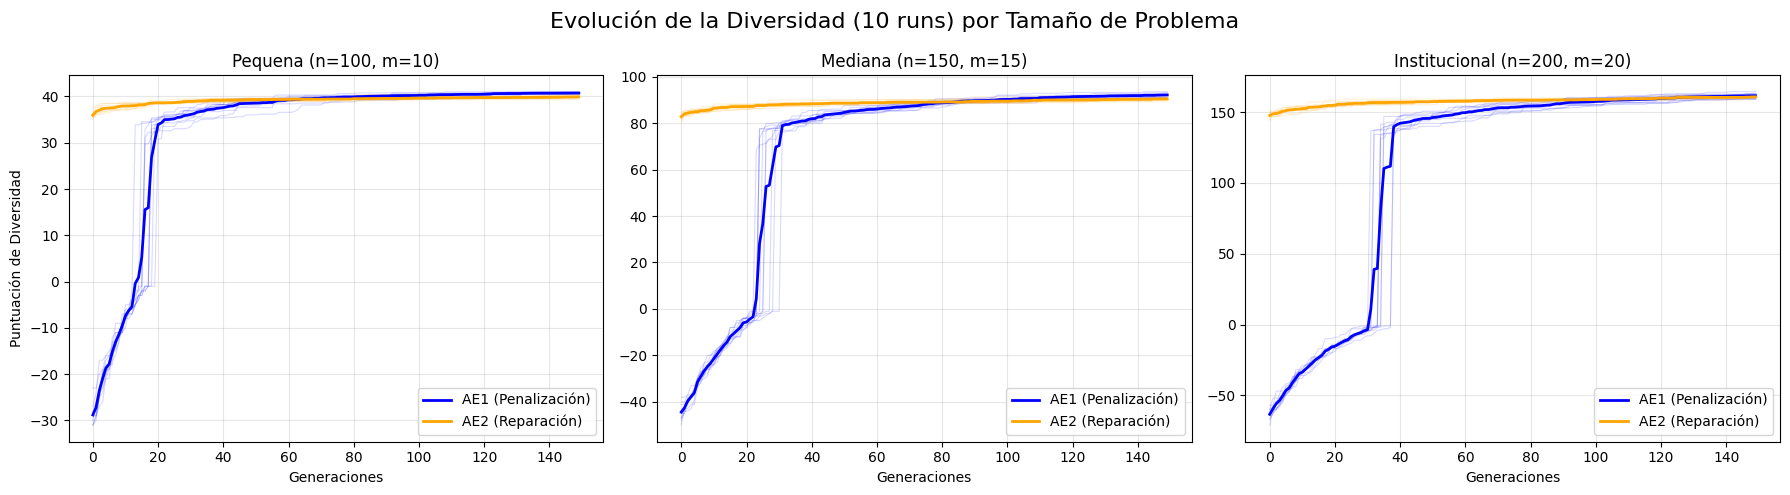

In [11]:
# Visualización Gráfica (1 fila, 3 columnas) — 10 runs individuales + media
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Evolución de la Diversidad (10 runs) por Tamaño de Problema', fontsize=16)

for idx, (case_name, data) in enumerate(all_results.items()):
    ax = axes[idx]

    # Invertimos el signo para graficar maximización
    hists_ae1 = np.array(data["AE1_hist"]) * -1
    hists_ae2 = np.array(data["AE2_hist"]) * -1

    # Runs individuales (líneas finas y transparentes)
    for run in hists_ae1:
        ax.plot(run, color='blue', alpha=0.15, linewidth=0.8)
    for run in hists_ae2:
        ax.plot(run, color='orange', alpha=0.15, linewidth=0.8)

    # Media (línea gruesa encima)
    ax.plot(np.mean(hists_ae1, axis=0), label="AE1 (Penalización)", color='blue', linewidth=2)
    ax.plot(np.mean(hists_ae2, axis=0), label="AE2 (Reparación)", color='orange', linewidth=2)

    ax.set_title(f"{case_name} (n={data['n']}, m={data['m']})")
    ax.set_xlabel("Generaciones")
    if idx == 0:
        ax.set_ylabel("Puntuación de Diversidad")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

Observando la gráfica, se puede ver como el enfoque de penalización comienza con peores valores de diversidad, pero rápidamente mejora para converger a una solución más óptima. El enfoque de reparación es mucho más estable en principio, manteniendose cerca del óptimo desde el inicio, pero no logra alcanzar la misma calidad de solución que el enfoque de penalización. Esto se debe a que el enfoque de reparación, al corregir las carteras antes de evaluarlas, limita la exploración del espacio de soluciones, lo que puede impedir que el algoritmo descubra combinaciones de acciones altamente descorrelacionadas que inicialmente eran inviables. En contraste, el enfoque de penalización permite una mayor diversidad en las soluciones exploradas, lo que facilita la convergencia hacia una cartera con mayor diversidad financiera. Véase como el test de Wilcoxon confirma que las diferencias entre ambos enfoques son estadísticamente significativas, respaldando la conclusión de que el enfoque de penalización es superior en este caso.

Para evaluar la calidad financiera de las carteras seleccionadas por cada enfoque, aplicamos un backtest sencillo de **buy and hold** sobre los activos elegidos. Construimos una cartera equiponderada con las acciones del mejor run de cada enfoque y calculamos el **drawdown** para visualizar las caidas relativas desde el maximo historico.

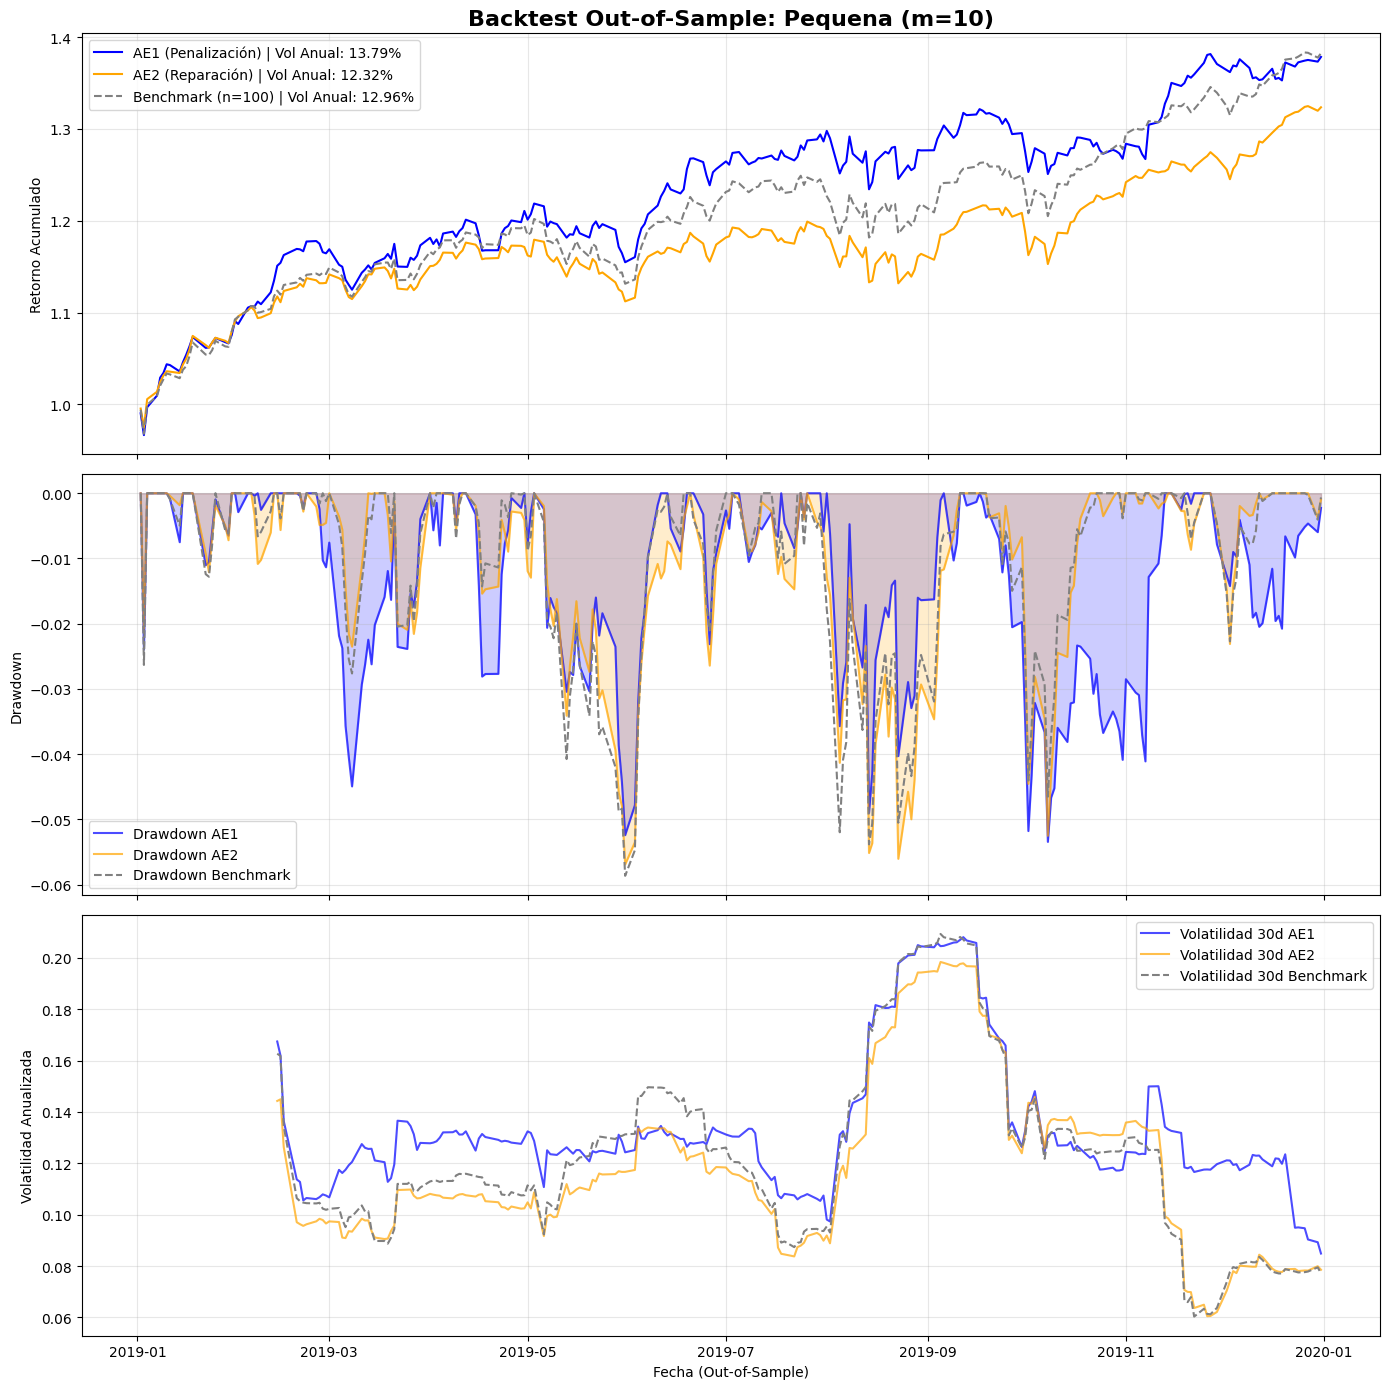

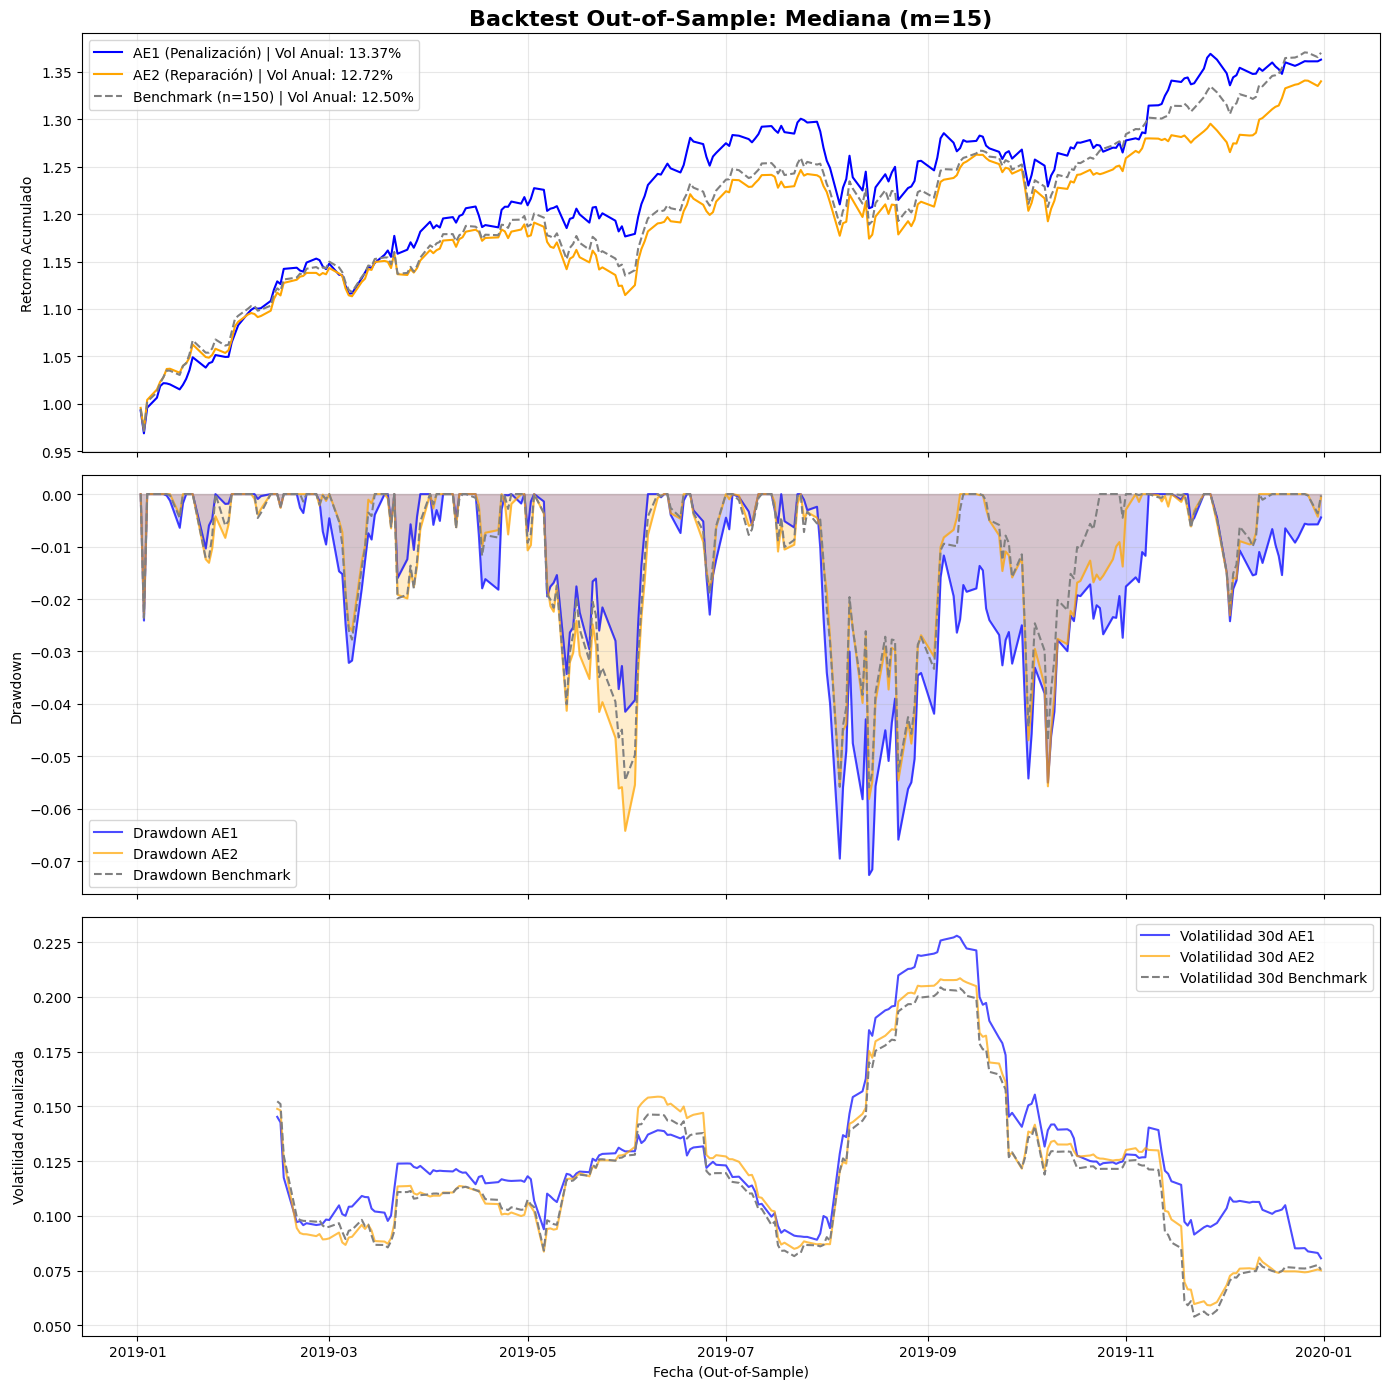

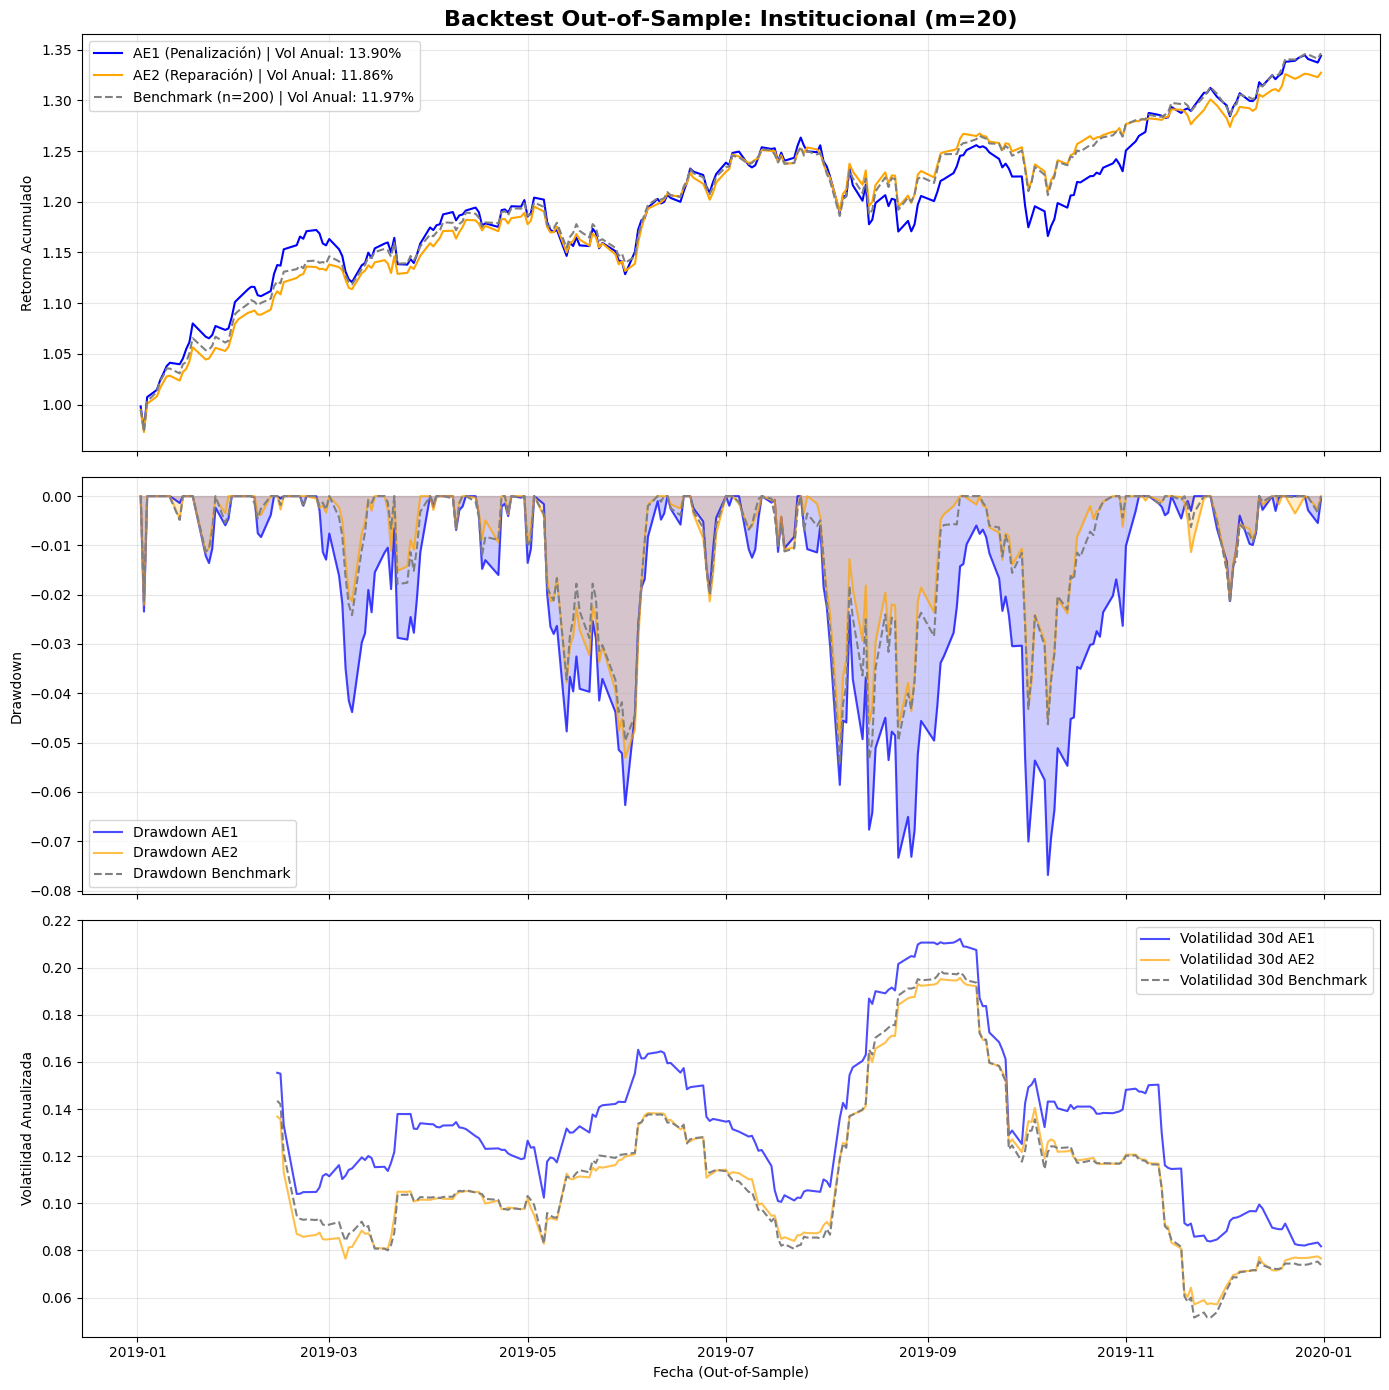

In [12]:
# Función para calcular el Drawdown.
def calculate_drawdown(cum_ret):
    running_max = cum_ret.cummax()
    drawdown = (cum_ret - running_max) / running_max
    return drawdown

for case_name, data_case in all_results.items():
    
    # Selección de los mejores cromosomas generados en la fase de entrenamiento.
    best_run_idx_ae1 = np.argmin(data_case["AE1_res"])
    best_run_idx_ae2 = np.argmin(data_case["AE2_res"])
    
    best_portfolio_ae1 = data_case["AE1_ind"][best_run_idx_ae1]
    best_portfolio_ae2 = data_case["AE2_ind"][best_run_idx_ae2]
    
    idx_ae1 = np.where(best_portfolio_ae1 == 1)[0]
    idx_ae2 = np.where(best_portfolio_ae2 == 1)[0]
    
    valid_tickers_case = tickers[:data_case["n"]]
    tickers_ae1 = [valid_tickers_case[i] for i in idx_ae1]
    tickers_ae2 = [valid_tickers_case[i] for i in idx_ae2]
        
    tickers_ae1_safe = [t for t in tickers_ae1 if t in returns_test.columns]
    tickers_ae2_safe = [t for t in tickers_ae2 if t in returns_test.columns]
    valid_tickers_case_safe = [t for t in valid_tickers_case if t in returns_test.columns]
    
    # Calculamos los retornos.
    portfolio_returns_ae1 = returns_test[tickers_ae1_safe].mean(axis=1)
    portfolio_returns_ae2 = returns_test[tickers_ae2_safe].mean(axis=1)
    benchmark_returns = returns_test[valid_tickers_case_safe].mean(axis=1)
    
    # Cálculo de Volatilidad Anualizada.
    vol_ae1 = portfolio_returns_ae1.std() * np.sqrt(252)
    vol_ae2 = portfolio_returns_ae2.std() * np.sqrt(252)
    vol_bench = benchmark_returns.std() * np.sqrt(252)
    
    # Cálculo de Volatilidad Móvil.
    rolling_vol_ae1 = portfolio_returns_ae1.rolling(window=30).std() * np.sqrt(252)
    rolling_vol_ae2 = portfolio_returns_ae2.rolling(window=30).std() * np.sqrt(252)
    rolling_vol_bench = benchmark_returns.rolling(window=30).std() * np.sqrt(252)
    
    # Cálculo de Retornos Acumulados y Drawdown en el periodo de test
    cum_returns_ae1 = (1 + portfolio_returns_ae1).cumprod()
    cum_returns_ae2 = (1 + portfolio_returns_ae2).cumprod()
    cum_benchmark = (1 + benchmark_returns).cumprod()
    
    dd_ae1 = calculate_drawdown(cum_returns_ae1)
    dd_ae2 = calculate_drawdown(cum_returns_ae2)
    dd_benchmark = calculate_drawdown(cum_benchmark)
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
    
    ax1.plot(cum_returns_ae1, label=f'AE1 (Penalización) | Vol Anual: {vol_ae1:.2%}', color='blue')
    ax1.plot(cum_returns_ae2, label=f'AE2 (Reparación) | Vol Anual: {vol_ae2:.2%}', color='orange')
    ax1.plot(cum_benchmark, label=f'Benchmark (n={data_case["n"]}) | Vol Anual: {vol_bench:.2%}', color='gray', linestyle='--')
    ax1.set_title(f'Backtest Out-of-Sample: {case_name} (m={data_case["m"]})', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Retorno Acumulado')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.fill_between(dd_ae1.index, dd_ae1, 0, color='blue', alpha=0.2)
    ax2.plot(dd_ae1, label='Drawdown AE1', color='blue', alpha=0.7)
    
    ax2.fill_between(dd_ae2.index, dd_ae2, 0, color='orange', alpha=0.2)
    ax2.plot(dd_ae2, label='Drawdown AE2', color='orange', alpha=0.7)
    
    ax2.plot(dd_benchmark, label='Drawdown Benchmark', color='gray', linestyle='--')
    ax2.set_ylabel('Drawdown')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    ax3.plot(rolling_vol_ae1, label='Volatilidad 30d AE1', color='blue', alpha=0.7)
    ax3.plot(rolling_vol_ae2, label='Volatilidad 30d AE2', color='orange', alpha=0.7)
    ax3.plot(rolling_vol_bench, label='Volatilidad 30d Benchmark', color='gray', linestyle='--')
    ax3.set_ylabel('Volatilidad Anualizada')
    ax3.set_xlabel('Fecha (Out-of-Sample)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

El backtesting muestra una de las limitaciones claras de intentar minimizar unicamente la correlacion en una cartera de valores. Minimizar esta métrica implica elegir acciones que se mueven de forma independiente, lo que minimiza el riesgo en caidas conjuntas pero tambien minimiza la capacidad de la cartera de beneficiarse de las subidas del mercado. Se debe tener en cuenta que la volatilidad afectará directamente al drawdown, por lo que no se puede pretender que un subconjunto de acciones con baja correlación entre sí tenga un drawdown menor que el mercado en su conjunto. De hecho, es posible que una cartera de acciones descorrelacionadas experimente caídas más pronunciadas que el índice general durante periodos de alta volatilidad, ya que cada acción puede reaccionar de manera diferente a los eventos del mercado. Véase como esto se verifica cuando, después de un periordo de drawdown signigicativo, el indicador de volatilidad incrementa ligeramente.

Los efectos anteriores según los algoritmos se observan más facilmente en la cartera institucional; el enfoque de penalización muestra una cartera menos volátil que el enfoque de reparación, lo que se traduce en picos de drawdown más bajos de forma general. Sin embargo, en carteras más pequeñas, esta ventaja se reduce, e incluso se invierte en algunos momentos. Esto se debe a que el enfoque de penalización conserva mejor una "herencia genética" de la cartera óptima encontrada, lo que le permite mantener una mayor consistencia en la selección de activos a lo largo del tiempo. En cambio, el enfoque de reparación, al modificar las carteras para cumplir con las restricciones, puede introducir cambios bruscos en la composición de la cartera, lo que puede resultar en una mayor volatilidad y, por ende, en drawdowns más pronunciados durante periodos de estrés en el mercado. En carteras pequeñas, el enfoque de penalización peca de sobreajuste, ya que se seleccionan los activos más descorrelacionados para ese periodo específico, que sumado a la poca cantidad, provoca mayor volatilidad y menor predictibilidad. El enfoque de reparación en este caso sobrevive por ser más "torpe", ya que es posible que durante la reparación se introduzcan activos que, aunque no sean los más descorrelacionados, tengan un comportamiento más estable durante el periodo de backtest, lo que puede resultar en drawdowns más bajos en ciertos momentos.